<a href="https://colab.research.google.com/github/nayankhanal/ml-class/blob/main/imbalanced.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DATA -> Balance , Imbalanced

## Balanced: Category (50-50)
## Imbalanced: Category (90-10)

In [1]:
# upsampling
# downsampling

In [2]:
import numpy as np
import pandas as pd

In [3]:
n_class_0 = 900
n_class_1 = 100

In [4]:
class_0 = pd.DataFrame({
    'feature_1': np.random.normal(0,1,900),
    'feature_2': np.random.normal(0,1,900),
    'target': [0] * n_class_0
})

In [5]:
class_0

,feature_1,feature_2,target
0,-0.633964,-1.776462,0
1,0.324071,0.774739,0
2,-1.828795,-0.335434,0
3,-0.527814,-0.118570,0
4,0.306200,0.988123,0
...,...,...,...
895,0.257131,-0.020455,0
896,0.887920,1.738518,0
897,0.208279,-0.178230,0
898,-1.007627,-0.764035,0


In [10]:
class_1 = pd.DataFrame({
    'feature_1': np.random.normal(2,1,100),
    'feature_2': np.random.normal(2,1,100),
    'target': [1] * n_class_1
})

In [11]:
df = pd.concat([class_0, class_1]).reset_index(drop=True)
df

,feature_1,feature_2,target
0,-0.633964,-1.776462,0
1,0.324071,0.774739,0
2,-1.828795,-0.335434,0
3,-0.527814,-0.118570,0
4,0.306200,0.988123,0
...,...,...,...
995,1.520808,2.169472,1
996,2.526144,2.678430,1
997,2.346457,1.346693,1
998,3.737795,2.020084,1


In [12]:
df_minority = df[df['target'] == 1]
df_majority = df[df['target'] == 0]

In [13]:
df_minority.shape, df_majority.shape

((100, 3), (900, 3))

# Upsample and Downsample

In [14]:
from sklearn.utils import resample
df_minority_upsampled = resample(df_minority, replace=True, n_samples=len(df_majority))

In [15]:
df_minority_upsampled.shape

(900, 3)

In [18]:
df_majority_upsampled = resample(df_majority, replace=True, n_samples=len(df_minority))
df_majority_upsampled.shape

(100, 3)

# SMOTE

### SMOTE (Synthetic Minority Oversampling Technique)

In [21]:
from sklearn.datasets import make_classification

In [38]:
X, y = make_classification(n_samples=1000, n_features=2, n_redundant=0, n_clusters_per_class=1, weights=[0.90], random_state=42)

In [39]:
X

array([[ 1.0735459 , -1.10133925],
       [ 0.75594526, -1.1723519 ],
       [ 1.35447877, -0.94852841],
       ...,
       [-2.15090138, -2.98937226],
       [ 2.45164689, -0.1566294 ],
       [ 3.64147835,  0.75692519]])

In [40]:
df1 = pd.DataFrame(X, columns=['f1','f2'])
df2 = pd.DataFrame(y, columns=['target'])
final_df = pd.concat([df1, df2], axis=1)

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

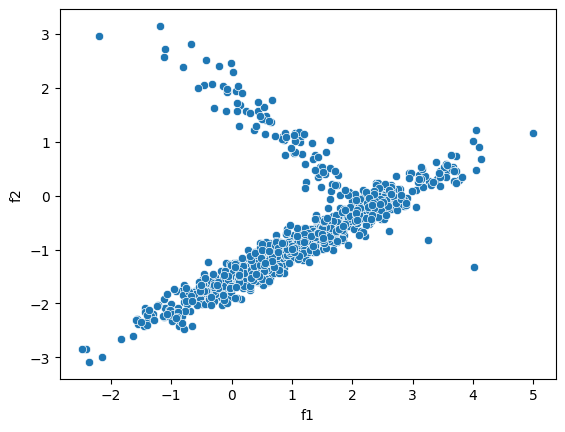

In [47]:
sns.scatterplot(data=final_df, x="f1",y='f2')
plt.show()

In [42]:
from imblearn.over_sampling import SMOTE

oversample = SMOTE()
X_res, y_res = oversample.fit_resample(X, y)